# Understanding Inflation through Data
### **Adam Mendoza**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, welch, find_peaks
from statsmodels.tsa.stattools import acf

In [47]:
bsp_cpi = pd.read_csv('..//data//bsp_cpibase2018_dataset.csv')
bsp_cpi['Date'] = pd.to_datetime(bsp_cpi['Year'].astype(str) + ' ' + bsp_cpi['Month'] + ' 1')
bsp_cpi.rename(columns={'All Items': 'CPI'}, inplace=True)
bsp_cpi = bsp_cpi[['Date', 'CPI']]
bsp_cpi.set_index('Date', inplace = True)

## **Preamble**
The change in the general level of prices in an economy is quantified through the **inflation rate**. In practice, this is often measured by determining how the **consumer price index** of a typical basket of goods vary in a span of a year. In other words

\begin{align}
I_{\mathrm{YoY}}&=\frac{\mathrm{CPI}_{t}-\mathrm{CPI}_{t-12}}{\mathrm{CPI}_{t-12}}*100\%.
\end{align}

In [48]:
inflation_rate = bsp_cpi['CPI'].pct_change(12) * 100
bsp_cpi['InflationRate'] = inflation_rate
inf = bsp_cpi['InflationRate'].dropna()

bsp_cpi.dropna().head()

,CPI,InflationRate
Date,,
1958-01-01,0.891176,6.25000
1958-02-01,0.891176,6.25000
1958-03-01,0.884623,5.46875
1958-04-01,0.884623,5.46875
1958-05-01,0.891176,6.25000


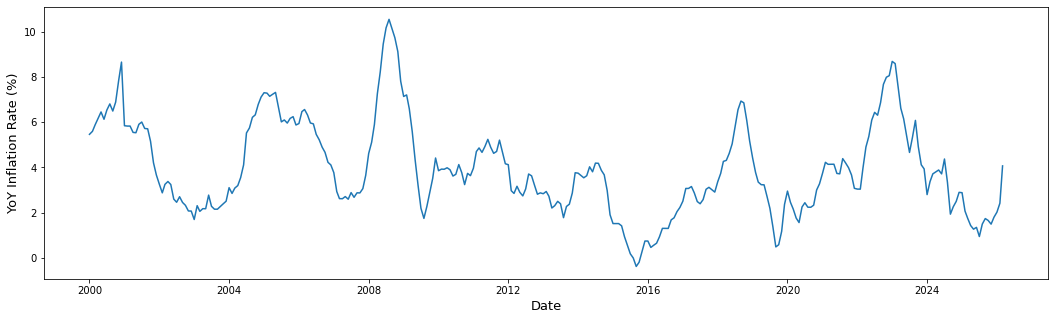

In [49]:
plt.figure(figsize=(18, 5))
plt.plot(inf.loc['2000':])
plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.show()

The plot of the year-on-year inflation rate, which we will simply call *inflation* henceforth, exhibits periods of inflation and disinflation (inflation rate goes down). However, there exists persistent sustained increase which can be explained by local and international events. 

**2004 - 2006** - Global oil price surge and expanded VAT law 

**2008 - 2009** - Global oil price surge and global food price crisis, the former being one of the causes. The consequent sharp dip can be explained by global 

**2016 - 2019** - *Build, Build, Build* leading to an increase in government spending and therefore, demand, amplified by *TRAIN Law* signed in Dec 2019. 

**2020 - 2024** - COVID-19 Pandemic, disrupting supply chains. The steady rise can be explained by decreasing production but increasing demands, resulting into overheat. 

In the current period, we are observing a dramatic rise of inflation due to the ongoing Iran war waged by US and Israel. In particular, the insecurity in the Strait of Hormuz constricts the global oil supply, leading to another global oil price surge. 

## **I. Smooth dynamics**

We ask if there are any determistic component in our inflation rate. In particular, we want to know if our inflation rate data has periodic characteristics. We will use three methods here: the Fast Fourier Transform (FFT), Welch's method, and autocorrelation to ensure that the seasonality that we will obtain are not artifacts of the finite data. 

**1. Fast Fourier Transform**

The Fast Fourier Transform, like its regular counterpart in continuous spaces, converts a signal from the time domain to the frequency domain. We then calculate the power spectral density (PSD) of the signal. The peaks of the PSD of the signal will give its dominant frequency. In other words, if there are strong seasonalities in the data, it will manifest as large power in the order of dominance.

In [50]:
n = len(inf)
dt = 1/12  # monthly spacing

inf_d = detrend(inf) # subtract the linear least squares fit from the data

window = np.hanning(n)  # to minimize spectral leakage due to discontinuities of endpoint values. this ensures high frequencies are not artifacts.
inf_w = inf_d * window # convolution


inf_fft = np.fft.fft(inf_w)
freqs = np.fft.fftfreq(n, d=dt)

mask = freqs > 0 # keep positive frequencies
freqs = freqs[mask]

psd_fft = (np.abs(inf_fft[mask])**2) / (np.sum(window**2)) # calculate the PSD

periods = 1 / freqs

# sort by period (ascending)
sorted_index = np.argsort(periods)
periods = periods[sorted_index]
psd_fft = psd_fft[sorted_index]

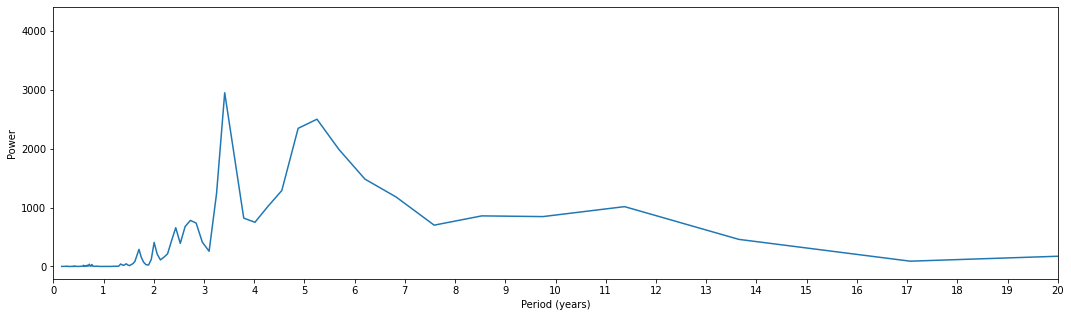

The period (in years) of the dominant seasonality are [68.25    3.4125  5.25  ]


In [51]:
# plot PSD
plt.figure(figsize=(18, 5))
plt.plot(periods, psd_fft)
plt.ylabel("Power")
plt.xlabel("Period (years)")
plt.xlim(0, 20)
plt.xticks(np.linspace(0, 20, 21))
plt.show()

# get dominant peaks (based on power)
peak_indices = np.argsort(psd_fft)[::-1][:3]
peak_periods_fft = periods[peak_indices]

print('The period (in years) of the dominant seasonality are {}'.format(peak_periods_fft))

From the Fast Fourier transform method above, we have obtained two *significant* peaks: 3.41 and 5.25. We will discard 68.25 since it is about the length scale of the inclusive year of the data. We will defer our interpretation later.


**2. Welch's Method**

This method segments the signal in an overlapping fashion, multiplied by a Hanning window, calculates the FFT in each segment, and averages the square of it. It is essentially the FFT above, but reduces spectral leakage further, making a more statistically reliable periodicity determination.

In [52]:
f, psd_welch = welch(inf, fs=12)

mask = f > 0
f = f[mask]
psd_welch = psd_welch[mask]

periods = 1 / f

sorted_idx = np.argsort(periods)
periods = periods[sorted_idx]
psd_welch = psd_welch[sorted_idx]

peaks, _ = find_peaks(psd_welch)

peak_idx = peaks[np.argsort(psd_welch[peaks])[::-1]]

peak_periods_welch = periods[peak_idx[:3]]

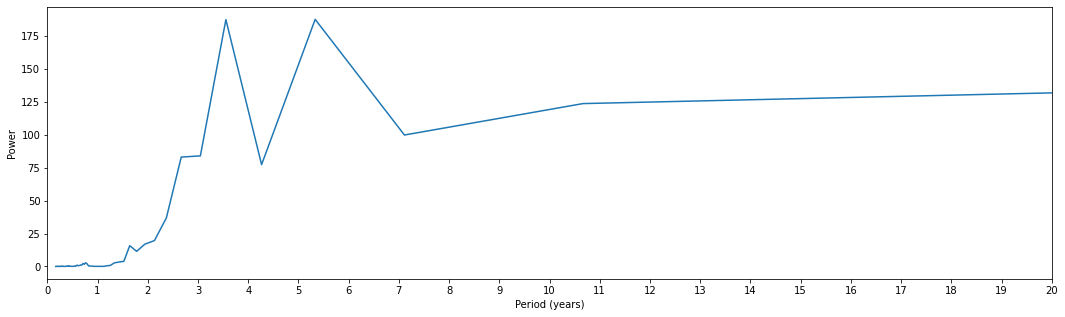

The period (in years) of the dominant seasonality are [5.33333333 3.55555556 1.64102564]


In [53]:
plt.figure(figsize=(18, 5))
plt.plot(periods, psd_welch)
plt.xlim(0, 20)
plt.xlabel("Period (years)")
plt.ylabel("Power")
plt.xticks(np.linspace(0, 20, 21))
plt.show()

print('The period (in years) of the dominant seasonality are {}'.format(peak_periods_welch))

**3. Autocorrelation**

Instead of calculating the PSD of the data, we find the correlation of the data with its shifted self. Mathematically, we want to find $\langle X(t) X(t+\tau)\rangle$. The more similar the data with its shifted self, the higher the autocorrelation. The idea is if the data has an underlying periodicity, it will manifest itself as a high autocorrelation at the lag time corresponding to its period.

In [62]:
acf_vals = acf(inf, nlags=100)
lags = np.arange(len(acf_vals))

peaks, _ = find_peaks(acf_vals, prominence=0.1)

# remove lag 0
peaks = peaks[lags[peaks] != 0]

dominant_lag = peaks[np.argmax(acf_vals[peaks])]

print("Dominant period (lag):", dominant_lag)
print("ACF value:", acf_vals[dominant_lag])

print('Dominant period (years):', dominant_lag/12)

Dominant period (lag): 42
ACF value: 0.2738355473502425
Dominant period (years): 3.5


Bottom line: the three method agrees that there is an underlying periodicity of $\sim 3.5$ years in the inflation data. The periodicity can be attributed to the link between the business cycle and the inflation rate. Economic growth leads to a decrease in the unemployment rate, leading to an economic overheat where the demand increases the supply, thus increasing the rate of inflation.

## **II. Noisy dynamics**

In [16]:
from statsmodels.tsa.seasonal import STL
stl = STL(inf, period=12)
res = stl.fit()
inf_d = res.resid

In [17]:
def tscott_bins(data):
    return int((2*len(data))**(1/3))

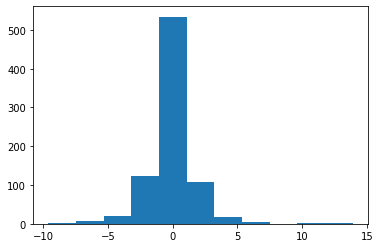

In [18]:
plt.hist(inf_d, bins = tscott_bins(inf_d))
plt.show()

In [21]:
from statsmodels.tsa.stattools import acf
acf_vals = acf(inf_d, nlags=50)

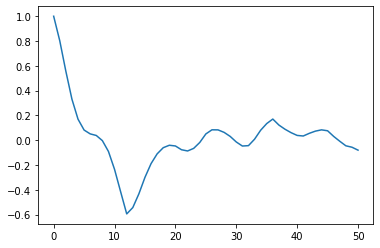

In [22]:
plt.plot(acf_vals)

In [19]:
def binned_msd(data, time, n_bins = None):

    if n_bins == None:
        n_bins = 100
    else:
        n_bins = int(n_bins)
        
    data = np.array(data)
    time = np.array(time)
    
    lag_times = []
    sq_diff = []

    for i in range(len(data)):
        for j in range(i+1, len(data)): 
            delta_t = time[j] - time[i] #take all possible pair of time points 
            squared_diff = (data[j] - data[i]) ** 2  #take their squared difference
            lag_times.append(delta_t)
            sq_diff.append(squared_diff)

    lag_times = np.array(lag_times)
    sq_diff = np.array(sq_diff)
    
    # define log lag time bins. make logarithmically spaced bins.
    log_min = np.log10(np.min(lag_times)) #ensure that the first logspace array val is np.min(lag_times)
    log_max = np.log10(np.max(lag_times)) #ensure that the last logspace array val is np.max(lag_times)
    bins = np.logspace(log_min, log_max, num=n_bins)

    msd_vals = []
    bin_centers = []
    msd_errors = []
    
    for k in range(len(bins)-1):
        bin_mask = (lag_times >= bins[k]) & (lag_times < bins[k+1]) 
        #make a boolean mask from the lag times
        if np.sum(bin_mask) > 0:
            bin_sq_diff = sq_diff[bin_mask]
            #get square differences that fall into the mask
            msd_vals.append(np.mean(bin_sq_diff)) 
            #calculate mean squared difference of sq_diff values falling to the mask
            bin_centers.append((bins[k] + bins[k+1])/2) 
            #take bin centers

            RMS = np.sqrt(np.mean((bin_sq_diff - np.mean(bin_sq_diff)) ** 2))
            msd_error = RMS / np.sqrt(np.sum(bin_mask))
            msd_errors.append(msd_error)

    msd_vals = np.abs(np.array(msd_vals))
    bin_centers = np.abs(np.array(bin_centers))
    msd_errors = np.abs(np.array(msd_errors))        
    
    return bin_centers[:int(len(bin_centers)/2)], msd_vals[:int(len(msd_vals)/2)], msd_errors[:int(len(msd_vals)/2)] #just take half 

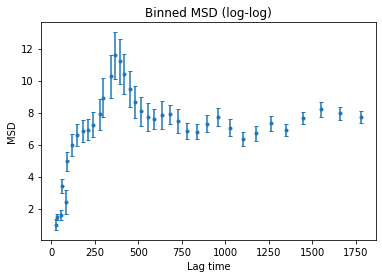

In [20]:
# convert time index to numeric (VERY important)
time_numeric = (inf.index - inf.index[0]).days  # or .astype(int) for ns

# compute MSD
tau, msd, err = binned_msd(inf_d, time_numeric)

# plot
plt.figure()
plt.errorbar(tau, msd, yerr=err, fmt='o', markersize=3, capsize=2)
plt.xlabel('Lag time')
plt.ylabel('MSD')
plt.title('Binned MSD (log-log)')
plt.show()

In [23]:
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(inf_d, lags=2).fit()
print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                  resid   No. Observations:                  819
Model:                     AutoReg(2)   Log Likelihood               -1234.095
Method:               Conditional MLE   S.D. of innovations              1.096
Date:                Wed, 15 Apr 2026   AIC                           2476.189
Time:                        21:48:08   BIC                           2495.012
Sample:                    03-01-1958   HQIC                          2483.413
                         - 03-01-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.038     -0.034      0.973      -0.076       0.074
resid.L1       0.9986      0.034     29.432      0.000       0.932       1.065
resid.L2      -0.2444      0.034     -7.205      0.0

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## **III. Predicting the future**

## **Summary and Conclusions**